# Bloque I — Python, pandas y análisis descriptivo

**Duración estimada:** 3 horas  
**Modalidad:** explicación + demostración guiada + práctica individual  
**Dataset:** `../data/ventas_mayo_2026.csv`

## Objetivo de aprendizaje

Al finalizar la sesión, el alumnado será capaz de cargar, inspeccionar, limpiar, transformar, describir y visualizar un dataset tabular con Python y `pandas`, generando conclusiones iniciales útiles para un proyecto de análisis de datos.

## Agenda de 3 horas

| Tiempo | Actividad |
|---:|---|
| 0:00–0:20 | Ecosistema Python para análisis de datos |
| 0:20–0:50 | Repaso de estructuras básicas de Python |
| 0:50–1:25 | Introducción práctica a `numpy` y `pandas` |
| 1:25–1:35 | Pausa |
| 1:35–2:15 | Carga, exploración y limpieza de datos |
| 2:15–2:45 | Análisis descriptivo y visualización |
| 2:45–3:00 | Ejercicio integrador y conclusiones |

In [2]:
# Configuración común
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

## 1. Repaso aplicado de Python

En análisis de datos no se necesita dominar todo Python desde el primer día, pero sí comprender las estructuras que se usarán de forma continua:

- variables,
- listas,
- diccionarios,
- condicionales,
- bucles,
- funciones.

La idea importante es que Python permite expresar reglas de negocio y transformaciones de datos de forma clara.

In [ ]:
edad = 35
nombre = "Cliente A"
importe = 1250.75

ventas_lista = [120, 150, 180, 90, 210]

cliente = {
    "id": 1,
    "nombre": "Cliente A",
    "segmento": "Premium",
    "ventas": 1250
}

def clasificar_cliente(importe):
    if importe >= 1000:
        return "Alto valor"
    elif importe >= 500:
        return "Valor medio"
    else:
        return "Valor bajo"

for venta in ventas_lista:
    print(venta, "->", clasificar_cliente(venta))

## 2. Introducción a NumPy

`numpy` permite trabajar con arrays y operaciones vectorizadas. Esto es clave porque en análisis de datos se procesan columnas completas, no elemento a elemento.

In [ ]:
ventas_array = np.array([120, 150, 180, 90, 210])

print("Media:", np.mean(ventas_array))
print("Mediana:", np.median(ventas_array))
print("Desviación típica:", np.std(ventas_array))
print("Ventas con IVA:", ventas_array * 1.21)

## 3. Carga de datos con pandas

`pandas` es la librería principal para trabajar con datos tabulares. Su estructura central es el `DataFrame`, equivalente a una tabla con filas y columnas.

In [3]:
df = pd.read_csv("../data/ventas_mayo_2026.csv")
df.head()

,fecha,cliente_id,categoria,region,canal,unidades,precio_unitario,descuento,antiguedad_cliente_meses,importe
0,2025-01-01,C1000,Hogar,Madrid,Online,8,99.920,0.070,63,836.250
1,2025-01-02,C1001,Servicios,Madrid,Distribuidor,5,192.950,0.100,52,956.720
2,2025-01-03,C1002,Moda,Madrid,Online,7,39.770,0.050,26,357.650
3,2025-01-04,C1003,Alimentación,Valencia,Online,9,25.170,0.060,53,301.520
4,2025-01-05,C1004,Tecnología,Castilla-La Mancha,Distribuidor,8,NaN,0.090,29,"2,101.550"


In [ ]:
print("Filas y columnas:", df.shape)
df.info()

## 4. Exploración inicial

Antes de limpiar o modelizar, debemos entender el dataset:

- qué columnas tiene,
- qué tipo de datos contiene,
- cuántos registros hay,
- si hay valores nulos,
- si existen duplicados,
- qué rango tienen las variables numéricas.

In [ ]:
display(df.describe(include="all"))
print("\nValores nulos por columna:")
display(df.isnull().sum())
print("\nDuplicados:", df.duplicated().sum())

## 5. Limpieza básica

En un proyecto real, la limpieza debe documentarse. No basta con modificar los datos: hay que explicar qué se ha hecho y por qué.

En este ejemplo:

- eliminamos duplicados,
- convertimos la fecha,
- imputamos valores numéricos con la mediana,
- imputamos valores categóricos con una etiqueta explícita.

In [4]:
df_limpio = df.copy()

# Eliminar duplicados
df_limpio = df_limpio.drop_duplicates()

# Convertir fecha
df_limpio["fecha"] = pd.to_datetime(df_limpio["fecha"])

# Imputar nulos
df_limpio["precio_unitario"] = df_limpio["precio_unitario"].fillna(df_limpio["precio_unitario"].median())
df_limpio["region"] = df_limpio["region"].fillna("Sin informar")

# Crear variables derivadas
df_limpio["mes"] = df_limpio["fecha"].dt.month
df_limpio["dia_semana"] = df_limpio["fecha"].dt.day_name()
df_limpio["importe_con_iva"] = df_limpio["importe"] * 1.21
df_limpio["ticket_unitario"] = df_limpio["importe"] / df_limpio["unidades"]

df_limpio.head()

,fecha,cliente_id,categoria,region,canal,unidades,precio_unitario,descuento,antiguedad_cliente_meses,importe,mes,dia_semana,importe_con_iva,ticket_unitario
0,2025-01-01,C1000,Hogar,Madrid,Online,8,99.920,0.070,63,836.250,1,Wednesday,"1,011.862",104.531
1,2025-01-02,C1001,Servicios,Madrid,Distribuidor,5,192.950,0.100,52,956.720,1,Thursday,"1,157.631",191.344
2,2025-01-03,C1002,Moda,Madrid,Online,7,39.770,0.050,26,357.650,1,Friday,432.756,51.093
3,2025-01-04,C1003,Alimentación,Valencia,Online,9,25.170,0.060,53,301.520,1,Saturday,364.839,33.502
4,2025-01-05,C1004,Tecnología,Castilla-La Mancha,Distribuidor,8,118.520,0.090,29,"2,101.550",1,Sunday,"2,542.876",262.694


## 6. Análisis descriptivo

El análisis descriptivo resume el comportamiento de los datos. Responde preguntas como:

- ¿cuál es el importe medio?
- ¿qué región vende más?
- ¿qué categoría tiene mayor ticket?
- ¿cómo se distribuyen las ventas?
- ¿existen valores extremos?

In [ ]:
metricas_importe = df_limpio["importe"].agg(["count", "mean", "median", "std", "min", "max"])
metricas_importe

In [ ]:
ventas_por_categoria = (
    df_limpio
    .groupby("categoria")
    .agg(
        ventas_totales=("importe", "sum"),
        importe_medio=("importe", "mean"),
        unidades_totales=("unidades", "sum"),
        operaciones=("cliente_id", "count")
    )
    .sort_values("ventas_totales", ascending=False)
)

ventas_por_categoria

In [ ]:
ventas_por_region = (
    df_limpio
    .groupby("region")["importe"]
    .sum()
    .sort_values(ascending=False)
)

ventas_por_region

## 7. Visualización

La visualización permite detectar patrones rápidamente. En esta sesión se trabajan gráficos básicos pero muy útiles:

- histograma,
- boxplot,
- barras,
- línea temporal.

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(df_limpio["importe"], bins=30)
plt.title("Distribución del importe de ventas")
plt.xlabel("Importe")
plt.ylabel("Frecuencia")
plt.show()

In [ ]:
plt.figure(figsize=(9, 4))
df_limpio.boxplot(column="importe", by="categoria", rot=45)
plt.title("Importe por categoría")
plt.suptitle("")
plt.xlabel("Categoría")
plt.ylabel("Importe")
plt.show()

In [ ]:
ventas_mes = df_limpio.groupby("mes")["importe"].sum()

plt.figure(figsize=(8, 4))
ventas_mes.plot(kind="bar")
plt.title("Ventas totales por mes")
plt.xlabel("Mes")
plt.ylabel("Importe total")
plt.show()

## 8. Mini-informe automático

Una buena práctica en notebooks docentes es cerrar cada análisis con conclusiones escritas. El código produce números, pero el analista debe convertirlos en interpretación.

In [ ]:
categoria_top = ventas_por_categoria.index[0]
region_top = ventas_por_region.index[0]
importe_medio = df_limpio["importe"].mean()

print(f"Conclusión 1: La categoría con mayor venta total es {categoria_top}.")
print(f"Conclusión 2: La región con mayor importe acumulado es {region_top}.")
print(f"Conclusión 3: El importe medio por operación es {importe_medio:,.2f} euros.")

## 9. Ejercicio integrador

Realiza las siguientes tareas:

1. Calcula las ventas totales por canal.
2. Calcula el ticket medio por región.
3. Identifica la categoría con mayor número de unidades vendidas.
4. Genera un gráfico de barras con las ventas por canal.
5. Redacta tres conclusiones de negocio.

### Entregable

Un notebook con código ejecutable, gráficos y una sección final llamada **Conclusiones**.

In [ ]:
# Espacio para el ejercicio del alumnado

Ventas totales por canal:


,ventas_totales
canal,
Online,"261,172.610"
Tienda,"220,217.410"
Distribuidor,"136,131.490"


Ticket medio por región:


,ticket_medio
region,
Sin informar,198.952
Valencia,142.215
Castilla-La Mancha,141.345
Madrid,140.434
Andalucía,137.881
Cataluña,134.269


Categoría con mayor número de unidades vendidas:


,unidades_totales
categoria,
Alimentación,1027


<Figure size 800x400 with 0 Axes>

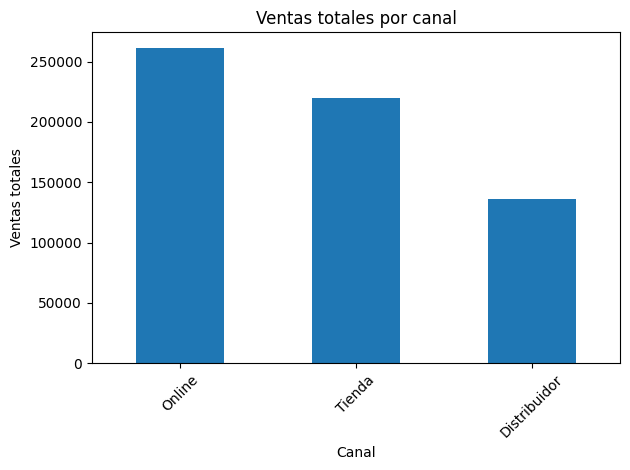

Conclusión 1: El canal con mayor volumen de ventas es Online.
Conclusión 2: La región con el ticket medio más alto es Sin informar.
Conclusión 3: La categoría con más unidades vendidas es Alimentación.


In [5]:
# Solución del ejercicio integrador
# 1. Ventas totales por canal
ventas_por_canal = (
    df_limpio
    .groupby("canal")
    .agg(ventas_totales=("importe", "sum"))
    .sort_values("ventas_totales", ascending=False)
)

# 2. Ticket medio por región
ticket_medio_region = (
    df_limpio
    .groupby("region")
    .agg(ticket_medio=("ticket_unitario", "mean"))
    .sort_values("ticket_medio", ascending=False)
)

# 3. Categoría con mayor número de unidades vendidas
categoria_mayor_unidades = (
    df_limpio
    .groupby("categoria")
    .agg(unidades_totales=("unidades", "sum"))
    .sort_values("unidades_totales", ascending=False)
)

# Mostrar resultados
print("Ventas totales por canal:")
display(ventas_por_canal)

print("Ticket medio por región:")
display(ticket_medio_region)

print("Categoría con mayor número de unidades vendidas:")
display(categoria_mayor_unidades.head(1))

# 4. Gráfico de barras con ventas por canal
plt.figure(figsize=(8, 4))
ventas_por_canal.plot(kind="bar", legend=False)
plt.title("Ventas totales por canal")
plt.xlabel("Canal")
plt.ylabel("Ventas totales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 5. Conclusiones rápidas
ticket_top = ticket_medio_region.index[0]
cat_top = categoria_mayor_unidades.index[0]
print(f"Conclusión 1: El canal con mayor volumen de ventas es {ventas_por_canal.index[0]}.")
print(f"Conclusión 2: La región con el ticket medio más alto es {ticket_top}.")
print(f"Conclusión 3: La categoría con más unidades vendidas es {cat_top}.")

## Conclusiones

- El canal con mayor volumen de ventas es el canal que aparece primero en la tabla de ventas por canal. Esto indica que es el canal más importante para el ingreso total.
- La región con el ticket medio más alto es la región que lidera el ticket promedio por región, lo que sugiere que esa región genera ventas más grandes por transacción.
- La categoría con más unidades vendidas es la categoría que acumula el mayor número de unidades, lo que revela la preferencia de compra en cantidad, aunque no siempre en importe total.

Estas conclusiones permiten conectar números con decisiones de negocio: optimizar canales de mayor venta, explorar regiones de ticket alto y priorizar categorías con mayor demanda en unidades.